In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import gzip

ASKUBUNTU_DIR = Path("../../data/raw/askubuntu")

print(ASKUBUNTU_DIR.resolve())
print(list(ASKUBUNTU_DIR.iterdir()))

D:\Projects\semantic_response_convergence\data\raw\askubuntu
[WindowsPath('../../data/raw/askubuntu/.git'), WindowsPath('../../data/raw/askubuntu/dev.txt'), WindowsPath('../../data/raw/askubuntu/heldout.txt'), WindowsPath('../../data/raw/askubuntu/README.md'), WindowsPath('../../data/raw/askubuntu/test.txt'), WindowsPath('../../data/raw/askubuntu/text_tokenized.txt.gz'), WindowsPath('../../data/raw/askubuntu/train_random.txt'), WindowsPath('../../data/raw/askubuntu/vector')]


In [3]:
corpus_path = ASKUBUNTU_DIR / "text_tokenized.txt.gz"

with gzip.open(corpus_path, "rt", encoding="utf-8") as f:
    for i in range(5):
        print(f.readline())

1	how to get the `` your battery is broken '' message to go away ?	everytime i turn on my computer , i see a message saying something like : your battery may be old or broken . etc ... i know my battery is not working . how can i make the message go away ?

3	how can i set the software center to install software for non-root users ?	how can i set the software center to allow non-root users to install stuff from the ubuntu repos without having to type in their password ? i 'm fully aware of the security implications , and i am willing to take the risk . fedora 12 shipped with something like this . ( by modifying the policykit configuration , i believe )

5	what are some alternatives to upgrading without using the standard upgrade system ?	what are some alternatives to upgrading without using the standard upgrade system ? suppose for example that i wanted to upgrade an ubuntu installation on a machine with a poor internet connection . what would my options be ? could i just use a standar

In [4]:
import gzip
import pandas as pd

rows = []

corpus_path = ASKUBUNTU_DIR / "text_tokenized.txt.gz"

with gzip.open(corpus_path, "rt", encoding="utf-8") as f:

    for i, line in enumerate(f):

        parts = line.rstrip("\n").split("\t")

        if len(parts) == 3:

            rows.append(
                {
                    "question_id": parts[0],
                    "title": parts[1],
                    "body": parts[2],
                }
            )

        if i >= 20000:
            break

askubuntu_df = pd.DataFrame(rows)

askubuntu_df.head()

,question_id,title,body
0,1,how to get the `` your battery is broken '' me...,"everytime i turn on my computer , i see a mess..."
1,3,how can i set the software center to install s...,how can i set the software center to allow non...
2,5,what are some alternatives to upgrading withou...,what are some alternatives to upgrading withou...
3,6,how to set up a headless server ?,i have a ubuntu development server at work . i...
4,7,how do i run a successful ubuntu hour ?,i 'm taking my be-stickered laptop to a coffee...


In [5]:
print("Rows:", len(askubuntu_df))

print(
    "Unique IDs:",
    askubuntu_df["question_id"].nunique()
)

Rows: 20001
Unique IDs: 20001


In [6]:
askubuntu_df["title_length"] = (
    askubuntu_df["title"]
    .str.split()
    .apply(len)
)

askubuntu_df["body_length"] = (
    askubuntu_df["body"]
    .str.split()
    .apply(len)
)

askubuntu_df[
    [
        "title_length",
        "body_length"
    ]
].describe()

,title_length,body_length
count,20001.000000,20001.000000
mean,9.519924,118.691815
std,3.911447,188.504913
min,1.000000,0.000000
25%,7.000000,46.000000
50%,9.000000,77.000000
75%,12.000000,129.000000
max,35.000000,5560.000000


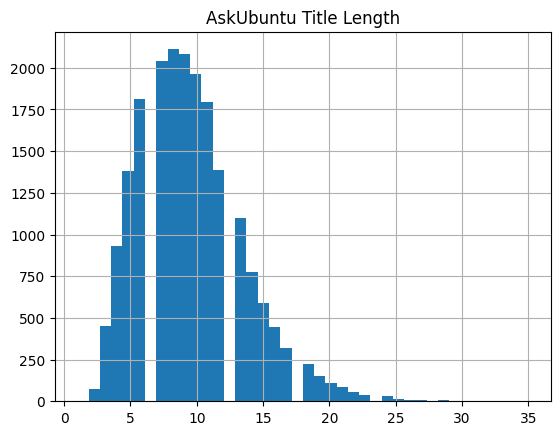

In [7]:
import matplotlib.pyplot as plt

askubuntu_df["title_length"].hist(
    bins=40
)

plt.title(
    "AskUbuntu Title Length"
)

plt.show()

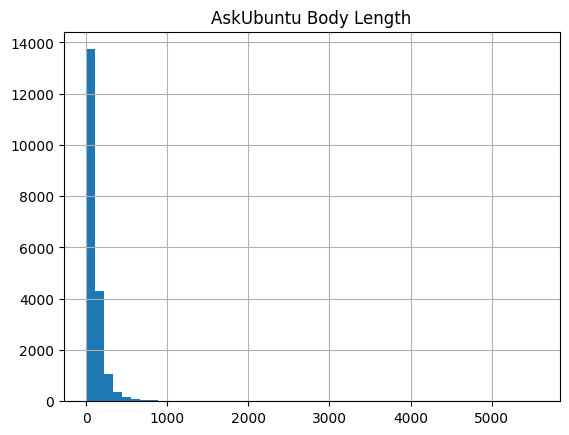

In [8]:
askubuntu_df["body_length"].hist(
    bins=50
)

plt.title(
    "AskUbuntu Body Length"
)

plt.show()

In [9]:
for filename in [
    "train_random.txt",
    "dev.txt",
    "test.txt",
]:
    print("\n" + "="*80)
    print(filename)

    with open(
        ASKUBUNTU_DIR / filename,
        "r",
        encoding="utf-8"
    ) as f:

        for _ in range(5):
            print(
                f.readline().strip()
            )


train_random.txt
262144	211039	227387 413633 113297 356390 256881 145638 296272 318659 86529 48563 53080 65996 334032 517236 470002 177348 502185 248772 457062 339049 265060 264524 15971 40468 422021 177982 513266 437762 318889 163711 491359 72668 523366 513514 119253 167106 395661 411198 284222 75399 352479 250977 476895 384032 379657 47506 214327 295133 165345 278645 40986 147959 498308 328292 49304 518817 418947 155658 522902 316447 487482 100000 436018 235318 314941 187592 439142 26205 180583 418425 41667 188060 147132 68407 191082 455272 486933 229959 153150 101914 254265 314232 384593 366741 227996 384171 302283 335076 452240 144708 395995 221644 392821 197651 404031 319280 257320 38398 287787 83851
491522	65911	155119 402211 310669 383107 131731 299465 163335 219514 459080 416153 369799 451295 392583 73818 271826 401323 236292 392481 78121 168780 285871 315524 408393 409033 126398 126478 220995 38343 124425 103110 477989 312867 382232 392656 23301 423981 223482 249927 218114 50

In [10]:
readme_path = ASKUBUNTU_DIR / "README.md"

with open(readme_path, "r", encoding="utf-8") as f:
    print(f.read())

## AskUbuntu Question Dataset

This repo contains a preprocessed collection of questions taken from [AskUbuntu.com](http://www.askubuntu.com) 2014 corpus dump. It also comes with 400*20 mannual annotations, marking pairs of questions as "similar" or "non-similar".

The XML-format raw corpus is available at this [Google drive directory](https://drive.google.com/folderview?id=0B-btHzfJjPnobXZ0MndjSkxkRkk#list).

### Reference
[1] [Semi-supervised Question Retrieval with Gated Convolutions](http://arxiv.org/abs/1512.05726). NAACL 2016

### Files & Formats

#### 1. Corpus file ``text_tokenized.txt.gz``
Each line of the corpus file contains three fields seperated by tab "\t" -- (1) the question ID, (2) the list of words in question title, and (3) the list of words in question body. For instance:
```
9     how do i enable automatic updates ?    update manager is constantly offering me updates ( e.g . security fixes , updates from ppas ) . how can i tell my ubuntu installation to automaticall

In [11]:
with open(
    ASKUBUNTU_DIR / "heldout.txt",
    "r",
    encoding="utf-8"
) as f:

    for _ in range(20):
        print(f.readline().strip())

184795
26114
410927
144777
169613
426297
370362
460309
174798
164819
34572
163434
492519
444666
140719
342934
432373
477503
37707
203694
